---
# Les métriques de qualité en régression
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/metriques-regression.png"  width="500" />
    <div>
    <font size="1.5">Image Source: Medium - Shreyas Mendhekar</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous verrons les métriques de qualité et de performances les plus utilisées en régression.  

## Table des matières
1. Pourquoi utiliser des métriques de qualité?
2. Le coefficient de corrélation R
3. Différentes métriques couramment utilisées
    1. $R^2$
    2. MSE
    3. RMSE
    4. MAE
4. Expérimentations

#### Importation des librairies utilisées.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

sns.set(color_codes=True)
np.random.seed(42)


Dans ce module, nous nous intéressons à quelques métriques utilisées pour évaluer la qualité des régresseurs. Ces métriques sont employées pour comparer différents modèles entre eux et choisir le meilleur. 

Plusieurs métriques sont mentionnées dans cette section, mais seules quelques-unes sont régulièrement utilisées dans la pratique.

## Pourquoi utiliser des métriques de qualité?

<div align="center">
    <img src= "./images/meeting.jpeg"  width="400" />
    <div>
    <font size="1.5">Image Source: https://www.pngall.com/meeting-png/</font>
    </div>
</div>

Au travail, il arrive souvent de discuter d'un problème à résoudre. Par exemple, la façon de traiter un ensemble de données difficilement acquises sur une longue période. On cherche à tirer le meilleur parti des efforts et des capitaux investis dans l'aventure. Plusieurs personnes suggèrent alors des solutions, mais on ne sait pas laquelle choisir. Chacun expose son point de vue à haute voix, en agitant les mains dans les airs (*hand waving*). Cela arrive régulièrement lors d'une séance de réflexion en groupe.

En fait, nous sommes entourés de gens compétents, et chacun peut aborder le problème sous un angle différent. Une telle discussion peut durer longtemps, mais il faut savoir la conclure pour pouvoir avancer. Pourquoi ne pas faire un test pour déterminer quelle est la meilleure solution? C'est déjà un pas en avant, mais les participants peuvent encore ne pas s'entendre sur la façon de comparer les solutions entre elles.

La méthode la plus pratique consiste à s'entendre sur une méthode de calcul, une métrique permettant de mesurer les performances de la solution proposée par chacun. On choisit ensuite, parmi toutes les solutions proposées, celle qui optimise la métrique. Par optimisation, on entend une minimisation ou une maximisation de cette métrique.

## Le coefficient de corrélation R

Avant d'aborder des différentes métriques, nous allons présenter le coefficient de corrélation. Il s'agit d'un outil puissant permettant de comparer deux ensembles de données $X$ et $Y$. Nous ne l'utilisons pas
comme une métrique, car sa valeur peut être négative ou positive. La qualité de la correspondance entre deux ensembles de données est
mieux représentée par la valeur absolue $|R|$, ou encore par le carré de celle-ci $R^2$. Cette dernière métrique est
discutée plus loin dans le tutoriel.

> À noter que dans la suite, on utilise la notation standard où $X$ et $Y$ sont deux ensembles de valeurs; ils
ne correspondent pas aux variables $x_{i}$ et à la réponse $y$ qu'on utilise dans la discussion sur la régression.

Le coefficient de corrélation entre deux ensembles de données $X$ et $Y$ se calcule comme suit
$$R = \rho(X,Y) = \dfrac{\frac{1}{n}\sum\limits_{i=1}^{n}(X^{(i)}-\mu_{X})(Y^{(i)}-\mu_{Y})}{\sigma_{X} \sigma_{Y}}$$

où $\mu_{X}$ et $\mu_{Y}$ sont les moyennes des ensembles et $\sigma_{X}$ et $\sigma_{Y}$ sont les écarts-types
des ensembles.

La figure suivante montre plusieurs exemples de distributions de valeurs en $X$ et $Y$ avec les valeurs de $R$ associées:

- la première ligne montre que plus le coefficient $R$ se rapproche des valeurs extrêmes -1 et 1 (ou que la valeur de $R^2$ se rapproche de 1), mieux la relation linéaire entre les variables est définie,
- la deuxième ligne montre que la valeur de $R$ change de signe selon l'orientation du nuage de points,
- la dernière ligne montre qu'une corrélation égale à 0 signifie que les variables ne sont pas corrélées
linéairement, elles peuvent néanmoins être corrélées non linéairement (par exemple, cercle, sinusoïde, croissant).

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/cluster-results.png" width="600"  width="200" />
    <div>
    <font size="1.5">Image Source: https://fr.wikipedia.org/wiki/Corrélation_(statistiques)/</font>
    </div>
</div>

Quelle est l'intuition derrière la formule du coefficient de corrélation? Le numérateur est la partie la plus importante dans la formule. Il est positif lorsque $X$ et $Y$ augmentent en même temps. Il est négatif lorsque $X$ augmente et $Y$ diminue en même temps. Le numérateur tend vers zéro lorsque les données sont très bruitées, c'est-à-dire lorsque $X$ et $Y$ varient de façon chaotique. C'est ce que l'on peut observer dans la figure précédente.

Le coefficient de corrélation R est omniprésent en analyse de données et s'avère particulièrement utile
pour comparer des résultats expérimentaux aux prédictions de modèles théoriques ou empiriques. Il
est à l'origine de plusieurs métriques de régression dont la plus connue, celle de $R^2$, est décrite plus loin.

## Différentes métriques couramment utilisées

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/podium-1-2-3.jpeg"  width="300" />
    <div>
    <font size="1.5">Image Source: https://s3.amazonaws.com/freestock-prod/450/freestock_58144363.jpg/</font>
    </div>
</div>

Supposons que l'on ait modélisé la réponse $y$ comme une fonction $f$ dépendant de $x$ et des paramètres $\Theta$.

$$y = f(x,\Theta)$$

La valeur prédite par le modèle pour une donnée $i$ est
$$\hat{y}^{(i)} = f(x^{(i)},\Theta)$$

La qualité d'une régression doit être mesurée à l'aide d'une valeur quantitative et non qualitative (« à l'œil »). C'est pour cette raison qu'on utilise une méthode de mesure de référence, c'est-à-dire, une métrique.

Si plusieurs métriques ont été proposées dans la littérature scientifique, toutes ne sont pas utilisées régulièrement dans la pratique. Nous allons voir lesquelles sont les plus courantes. 

Par convention, nous utiliserons également les acronymes des noms anglais, car ils sont omniprésents dans la littérature.

Il faut toutefois mentionner que plusieurs métriques maison sont conçues et mises en œuvre dans le milieu industriel. Ces métriques spécialisées permettent d'optimiser des processus basés sur des chaînes d'opérations très complexes.

### R carré (*R-squared* ou $R^2$)

C'est probablement la métrique la plus importante et la plus utilisée, car c'est la plus intuitive de toutes! La qualité d'une
régression est souvent déterminée visuellement en affichant les valeurs mesurées de la
réponse $y^{(i)}$ en fonction des valeurs prédites $\hat{y}^{(i)}$. On peut ensuite calculer
le coefficient de corrélation R. Plus $R^2$ est proche de $1$, meilleure est l'adéquation entre les
deux ensembles de données, et donc meilleur est le modèle utilisé.

Une formulation utile de la métrique de $R^2$ est la suivante:

$$R^2 = 1-\frac{\text{SSE}}{\text{SST}}$$


avec la variance des erreurs du modèle correspondant à
$$\text{SSE} = \frac{1}{n-1}\sum\limits_{i=1}^{n}(y^{(i)}-\hat{y}^{(i)})^{2},$$

La variance totale du signal dans les données est quant à elle donnée par :
$$\text{SST} = \frac{1}{n-1}\sum\limits_{i=1}^{n}(y^{(i)}-\bar{y})^{2}.$$

La valeur de $R^2$ correspond ainsi au pourcentage de la variance totale qui est expliqué par le modèle
de régression. Remplacez le mot variance par information; le modèle explique la fraction
$R^2$ de toute l'information contenue dans les données. C'est beaucoup plus parlant ainsi!
Cette métrique doit être maximisée.

Il est possible que la valeur de $R^2$ soit négative lorsque calculée avec la formule ci-dessus!!! Cela se produit lorsque le modèle recalé fait des prédictions **pires** que la simple prédiction de la moyenne des valeurs de l'ensemble y_test. En résumé, plus le modèle fait des prédictions différentes du signal original, plus la valeur de $R^2$ est négative.

### Erreur carrée moyenne (*mean squared error* ou MSE)

Il s'agit de la métrique de base et la plus courante dans la pratique. Cette métrique doit être minimisée.

$$\text{MSE} = \frac{1}{n}\sum\limits_{i=1}^{n}(y^{(i)}-\hat{y}^{(i)})^{2}$$

### Racine de l'erreur carrée moyenne (*root mean squared error* ou RMSE)

C'est la racine carrée de la précédente. Elle est plus facilement interprétable. Elle correspond à
l'écart-type de l'erreur de régression. Cette métrique doit être minimisée.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n}(y^{(i)}-\hat{y}^{(i)})^{2} }$$

### Erreur absolue médiane (*median absolute error* ou MAE)

Les métriques précédentes sont très sensibles aux valeurs aberrantes (*outliers*) dans les données. La qualité d'une régression est fortement affectée par leur présence.

Les métriques basées sur la médiane sont plus robustes face à ces valeurs aberrantes. Elles sont toutefois moins utilisées dans la pratique, principalement pour deux raisons. La première est que les gens sont plus familiers avec la moyenne qu'avec la médiane d'un ensemble de données. La seconde est qu'en début de projet, les données sont nettoyées et la plupart des valeurs aberrantes sont éliminées à cette étape. Cette métrique doit être minimisée.

$$\text{MAE} = \text{median}(|y_{1}-\hat{y}_{1}|,\cdots,|y_{n}-\hat{y}_{n}|)$$

## Expérimentations
#### Préparation des données

Dans ce qui suit, nous allons effectuer les opérations suivantes:


- générer un ensemble de données $(x,y)$ où la réponse $y$ est un cosinus de $x$ additionné de bruit gaussien,
- séparer les données $(x,y)$ en ensembles d'entraînement et de test,
- entraîner plusieurs modèles de régression (des polynômes de degrés 1, 3 et 6) avec l'ensemble d'entraînement,
- prédire les réponses pour les données de test,
- calculer une métrique de performance pour chaque modèle à l'aide des valeurs réelles et prédites lors du test ;
- comparer les valeurs des métriques.

**Remarque** : vous pouvez expérimenter en modifiant le nombre de données et le niveau de bruit dans la cellule suivante pour voir comment cela affecte les régressions ainsi que les valeurs des métriques de performances. 

In [2]:
# Nombre de données
N = 15

# Niveau de bruit
sigma = 0.5

# Plage des valeurs de x
x_min, x_max = -2.5, 10.0
xx = np.linspace(x_min, x_max, 300)

# Données expérimentales. Les valeurs de x sont échantillonnées aléatoirement dans la plage de valeurs précédente
X = np.random.uniform(x_min, x_max, N)
y = np.cos(X/2) + np.random.normal(0, sigma, N)

#### Séparation des données en ensembles d'entraînement (80 %) et de test (20 %)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Nous allons effectuer la régression de trois modèles polynomiaux de degrés 1, 3, et 6. 
Pour ce faire, nous utiliserons la fonction  
[`polyfit`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) qui effectue une régression des moindres carrés (c'est-à-dire en minimisant la RMSE) pour un polynôme de degré donné.

In [4]:
models = {
    "Deg1": np.polyfit(X_train, y_train, 1),
    "Deg3": np.polyfit(X_train, y_train, 3),
    "Deg6": np.polyfit(X_train, y_train, 6),
}

Calculons les réponses prédites par chaque modèle pour les valeurs X de test.

In [5]:
y_pred = {name: np.polyval(coefs, X_test) for name, coefs in models.items()}

Calculons maintenant la réponse prédite par chaque modèle sur la plage des valeurs expérimentales.

In [6]:
y_smooth = {name: np.polyval(coefs, xx) for name, coefs in models.items()}

# Vraies valeurs de la fonction originale sur la plage des valeurs de x.
y_true = np.cos(xx/2)

#### Affichage des résultats de régression

Dans chaque panneau, les points noirs correspondent aux valeurs d'entraînement et les points rouges aux valeurs de test.

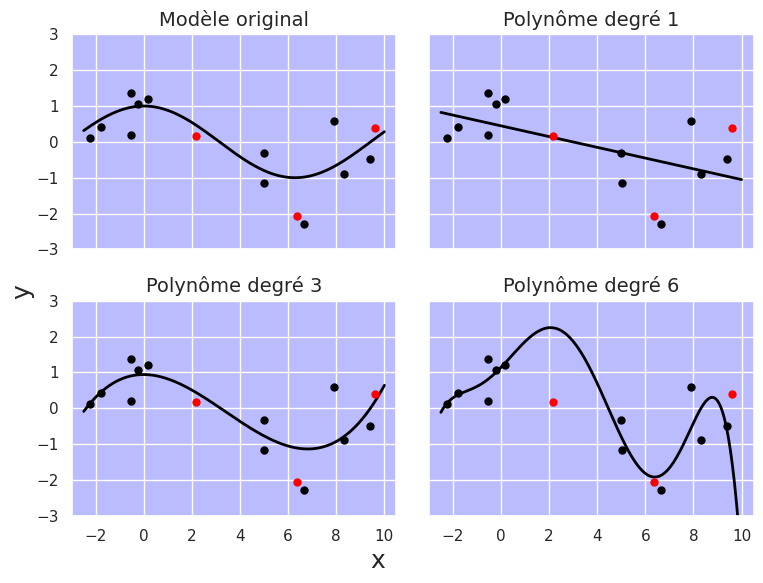

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
axes = axes.ravel()

titles = [
    "Modèle original",
    "Polynôme degré 1",
    "Polynôme degré 3",
    "Polynôme degré 6",
]

curves = [y_true, y_smooth["Deg1"], y_smooth["Deg3"], y_smooth["Deg6"]]

for ax, title, curve in zip(axes, titles, curves):
    ax.plot(xx, curve, color="black", linewidth=2)
    ax.plot(X_train, y_train, "o", color="black", markersize=5)
    ax.plot(X_test, y_test, "o", color="red", markersize=5)

    ax.set_title(title, fontsize=14)
    ax.set_facecolor("#BBBBFF")
    ax.set_xlim(x_min - 0.5, x_max + 0.5)
    ax.set_ylim(-3, 3)

fig.text(0.5, 0.04, "x", ha="center", fontsize=18)
fig.text(0.04, 0.5, "y", va="center", rotation="vertical", fontsize=18)
fig.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


On remarque que le polynôme de degré 1 est trop simple (sous-apprentissage) et celui de degré 6 est trop complexe (sur-apprentissage) pour reproduire la distribution des données. Le polynôme de degré 3 est donc le meilleur.

#### Affichage des valeurs des métriques de performance

In [8]:
def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

results = {
    name: compute_metrics(y_test, y_pred[name])
    for name in y_pred
}

df_results = pd.DataFrame(results).T
df_results


,MAE,MSE,RMSE,MedAE,R2
Deg1,1.004754,1.464316,1.210089,1.394033,-0.178891
Deg3,0.470758,0.342735,0.585436,0.260179,0.724071
Deg6,1.406794,2.768245,1.663804,2.002255,-1.228657


Les quatre premières métriques sont minimales pour le modèle polynomial de degré 3. La métrique du $R^2$  est maximale pour le même modèle. Notez que la valeur de $R^2$ est inférieure à 0 pour les deux autres modèles. Cela signifie qu'un modèle constant égal à la valeur moyenne des données d'entraînement y_train aurait été un meilleur modèle dans chaque cas!

Comme nous l'avons vu, les métriques permettent de comparer quantitativement les modèles de régression utilisés. Elles ont toutes identifié le deuxième modèle comme étant le meilleur. Toutefois, il arrive que le modèle optimal varie entre les métriques, notamment avec des données très bruitées ou aberrantes.

Le jeu de données ne contient que 15 données, ce qui est très peu. L'objectif était surtout de démontrer le fonctionnement des métriques. Nous constatons cependant que si nous augmentons le nombre de données (en testant la valeur de N), les résultats ne pointent pas toujours vers le deuxième modèle. Au-delà d'un certain seuil, la différence entre le second et le troisième modèle est minime. 